In [ ]:
# Verificación del entorno GPU
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo : {device}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version     : {torch.version.cuda}")
    print(f"Memoria total    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Sin GPU detectada — el modelo correrá en CPU.")


# Ejercicio: Clasificación con Redes Neuronales

En este ejercicio, trabajarás con una red neuronal para resolver un problema de clasificación no lineal. A diferencia del ejemplo anterior, utilizaremos una distribución de puntos diferente para explorar cómo las redes neuronales pueden aprender a separar clases en un espacio latente.

Completa el código en las celdas correspondientes para entrenar y evaluar tu modelo.

In [320]:
# Librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
import torch
import torch.nn as nn
import torch.optim as optim

# Para reproducibilidad
random_seed = 123
np.random.seed(random_seed)
torch.manual_seed(random_seed)

## Creación del conjunto de datos

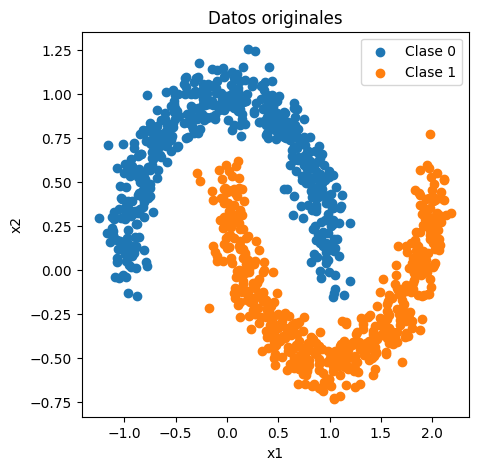

x shape:  (1000, 2)
y shape:  (1000,)


In [321]:
# Crear un conjunto de datos no lineal: dos lunas
x, y = datasets.make_moons(n_samples=1000, noise=0.1, random_state=random_seed)

# Visualización de los datos
plt.figure(figsize=(5,5))
plt.scatter(x[y==0, 0], x[y==0, 1], label='Clase 0')
plt.scatter(x[y==1, 0], x[y==1, 1], label='Clase 1')
plt.title('Datos originales')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

print("x shape: ", x.shape)
print("y shape: ", y.shape)

## Conversión de datos a tensores

In [322]:
# Convertir los datos a tensores de PyTorch
# COMPLETA EL CÓDIGO AQUÍ
X_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)

print('Tensor de entrada:', X_tensor.shape)
print('Tensor de salida:', y_tensor.shape)

Tensor de entrada: torch.Size([1000, 2])
Tensor de salida: torch.Size([1000, 1])


## Definición de la red neuronal

In [323]:
# Define tu modelo aquí
# COMPLETA EL CÓDIGO AQUÍ
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        neurons = 8
        self.hidden1 = nn.Linear(2, neurons)
        self.hidden2 = nn.Linear(neurons, 2)
        self.classifier = nn.Sequential(
            nn.Linear(2, 1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU()


    def forward(self, X):
        Z1 = self.relu(self.hidden1(X))
        Z2 = self.relu(self.hidden2(Z1))
        
        y_hat = self.classifier(Z2)
        return y_hat
    
    def latent_representation(self, X):
        Z1 = self.relu(self.hidden1(X))
        Z2 = self.relu(self.hidden2(Z1))
        
        return Z2
    
model = SimpleNet()
print("model", model)
        

model SimpleNet(
  (hidden1): Linear(in_features=2, out_features=8, bias=True)
  (hidden2): Linear(in_features=8, out_features=2, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=2, out_features=1, bias=True)
    (1): Sigmoid()
  )
  (relu): ReLU()
)


## Entrenamiento del modelo

In [324]:
# Entrena tu modelo aquí
# COMPLETA EL CÓDIGO AQUÍ

criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.2, weight_decay=0.0001)

epochs = 10000
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()

    y_pred = model(X_tensor)

    loss = criterion(y_pred, y_tensor)

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f'Época {epoch+1:3d}/{epochs} - Función de costo: {loss.item():.6f}')

    
    

Época  20/10000 - Función de costo: 0.677884
Época  40/10000 - Función de costo: 0.615571
Época  60/10000 - Función de costo: 0.495602
Época  80/10000 - Función de costo: 0.405430
Época 100/10000 - Función de costo: 0.348210
Época 120/10000 - Función de costo: 0.312681
Época 140/10000 - Función de costo: 0.289643
Época 160/10000 - Función de costo: 0.274489
Época 180/10000 - Función de costo: 0.264097
Época 200/10000 - Función de costo: 0.256436
Época 220/10000 - Función de costo: 0.250432
Época 240/10000 - Función de costo: 0.245463
Época 260/10000 - Función de costo: 0.241140
Época 280/10000 - Función de costo: 0.237211
Época 300/10000 - Función de costo: 0.233431
Época 320/10000 - Función de costo: 0.229579
Época 340/10000 - Función de costo: 0.225424
Época 360/10000 - Función de costo: 0.220799
Época 380/10000 - Función de costo: 0.215457
Época 400/10000 - Función de costo: 0.209065
Época 420/10000 - Función de costo: 0.201462
Época 440/10000 - Función de costo: 0.192371
Época 460/

## Evaluación del modelo

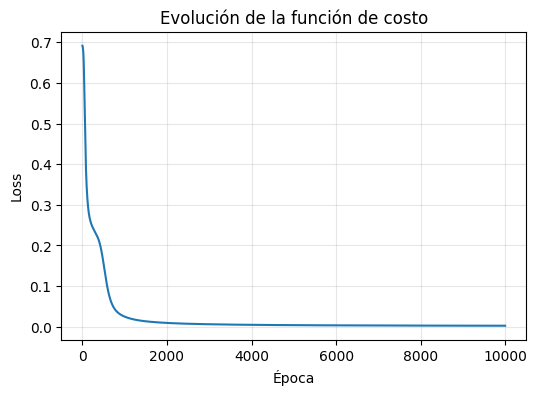

Exactitud sobre el conjunto de entrenamiento: 1.0000


In [325]:
# Evalúa tu modelo aquí
# COMPLETA EL CÓDIGO AQUÍ

plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title('Evolución de la función de costo')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

with torch.no_grad():
    probs = model(X_tensor)
    preds = (probs >= 0.5).float()
    accuracy = (preds.eq(y_tensor).sum().item()) / len(y_tensor)

print(f'Exactitud sobre el conjunto de entrenamiento: {accuracy:.4f}')


## Visualización de resultados

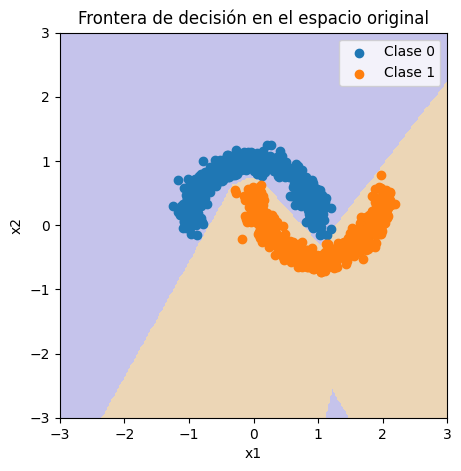

In [326]:
# Visualiza los resultados aquí
# COMPLETA EL CÓDIGO AQUÍ
from matplotlib.colors import ListedColormap

region_cmap = ListedColormap([
    "#c5c3eb",  # lavanda claro (región exterior)
    "#ecd6b6"   # beige claro (región interior)
])

point_colors = ["#0000ff", "#ff7f0e"]  # azul y naranja

# Función para graficar la frontera de decisión
def plot_predictions_torch(model, axes):
    x0s = np.linspace(axes[0], axes[1], 200)
    x1s = np.linspace(axes[2], axes[3], 200)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_grid = np.c_[x0.ravel(), x1.ravel()]

    X_grid_tensor = torch.tensor(X_grid, dtype=torch.float32)
    with torch.no_grad():
        y_prob = model(X_grid_tensor).numpy().reshape(x0.shape)

    y_class = (y_prob >= 0.5).astype(float)
    plt.contourf(x0, x1, y_class, cmap=region_cmap, alpha=1)

plt.figure(figsize=(5,5))
plot_predictions_torch(model, [-3, 3, -3, 3])
plt.title('Frontera de decisión en el espacio original')
plt.scatter(x[y==0,0], x[y==0,1], label='Clase 0')
plt.scatter(x[y==1,0], x[y==1,1], label='Clase 1')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

In [327]:
# Extraer la representación latente de dimensión 2
with torch.no_grad():
    z_l_1 = model.latent_representation(X_tensor).numpy()

print('Forma de la representación latente:', z_l_1.shape)
z_l_1[:5]

Forma de la representación latente: (1000, 2)


array([[4.355966 , 0.       ],
       [3.095653 , 0.       ],
       [2.6450067, 0.       ],
       [0.       , 0.       ],
       [4.4971356, 0.       ]], dtype=float32)

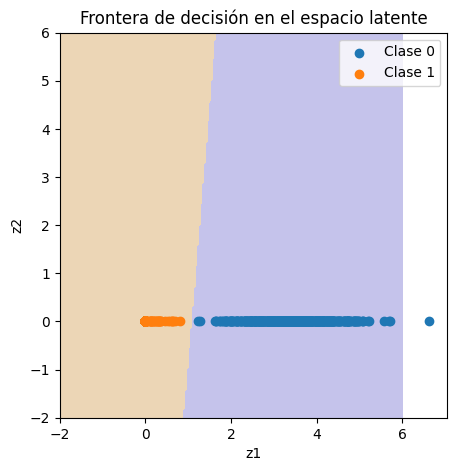

In [328]:


# Visualización en el espacio latente
plt.figure(figsize=(5,5))
plot_predictions_torch(model.classifier, [-2, 6, -2, 6])
plt.title('Frontera de decisión en el espacio latente')
plt.scatter(z_l_1[y==0,0], z_l_1[y==0,1], label='Clase 0')
plt.scatter(z_l_1[y==1,0], z_l_1[y==1,1], label='Clase 1')

plt.xlabel('z1')
plt.ylabel('z2')
plt.legend()
plt.show()